In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot  as mlt


In [3]:
import pandas as pd

df = pd.read_csv('../datasets/sp500.csv')

In [4]:
df.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,1950-01-03,16.66,16.66,16.66,16.66,1260000,0,0
1,1950-01-04,16.85,16.85,16.85,16.85,1890000,0,0
2,1950-01-05,16.93,16.93,16.93,16.93,2550000,0,0
3,1950-01-06,16.98,16.98,16.98,16.98,2010000,0,0
4,1950-01-09,17.08,17.08,17.08,17.08,2520000,0,0


<Axes: >

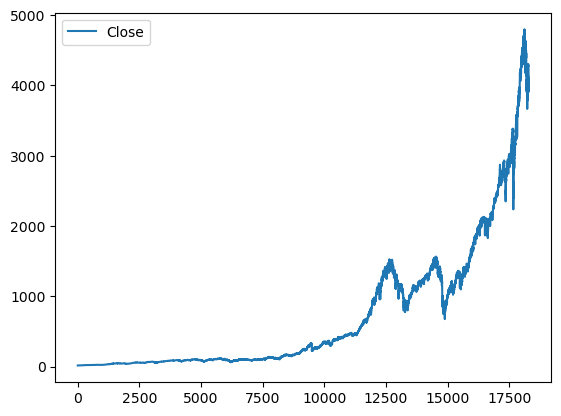

In [12]:
df.plot.line(y="Close" , use_index= True)

In [6]:
del df["Dividends"]
del df["Stock Splits"]


In [7]:
df.head()

,Date,Open,High,Low,Close,Volume
0,1950-01-03,16.66,16.66,16.66,16.66,1260000
1,1950-01-04,16.85,16.85,16.85,16.85,1890000
2,1950-01-05,16.93,16.93,16.93,16.93,2550000
3,1950-01-06,16.98,16.98,16.98,16.98,2010000
4,1950-01-09,17.08,17.08,17.08,17.08,2520000


In [ ]:
df['Tommorow'] = df['Close'].shift(-1)

In [13]:
df['Target'] = (df["Tommorow"] > df["Close"]).astype(int)

In [14]:
df  = df.loc["1990-01-01":].copy()

In [20]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators = 100 , min_samples_split = 100 , random_state= 42)

train = df.iloc[:-100]
test = df.iloc[-100:]

predictors = ["Close", "Volume", "Open", "High", "Low"]

model.fit(train[predictors],train["Target"])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,100
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
from sklearn.metrics import precision_score
preds = model.predict(test[predictors])
preds = pd.Series(preds, index = test.index)
precision_score(test['Target'] , preds)



0.4936708860759494

<Axes: >

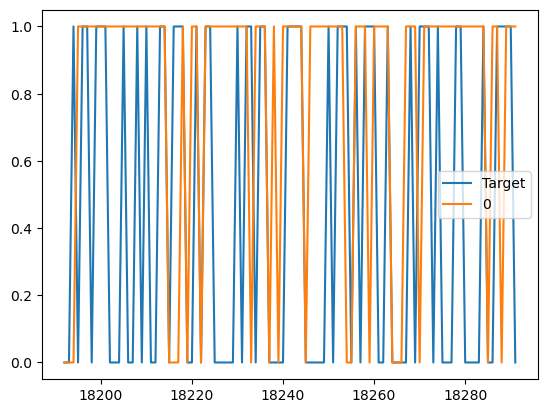

In [25]:
combined = pd.concat([test["Target"],preds],axis =1 )
combined.plot()